# Detecção de Objetos com YOLOS-Small

Neste notebook, utilizaremos o modelo [hustvl/yolos-small](https://huggingface.co/hustvl/yolos-small) do Hugging Face para realizar a detecção de objetos nas imagens da pasta `imagens`.

In [1]:
import os
import torch
from PIL import Image, ImageDraw, ImageFont
from transformers import YolosImageProcessor, YolosForObjectDetection
import matplotlib.pyplot as plt

# 1. Carregar o modelo e o processador de imagem
model_id = "hustvl/yolos-small"
print(f"Carregando o modelo {model_id}...")

image_processor = YolosImageProcessor.from_pretrained(model_id)
model = YolosForObjectDetection.from_pretrained(model_id)

print("Modelo carregado com sucesso!")

Carregando o modelo hustvl/yolos-small...


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Modelo carregado com sucesso!


In [ ]:
def detect_and_show(image_path, threshold=0.4):
    """Realiza a detecção em uma imagem e exibe o resultado."""
    image = Image.open(image_path).convert("RGB")
    
    # Prepara a imagem para o modelo
    inputs = image_processor(images=image, return_tensors="pt")
    
    # Inferência
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Pós-processamento: converter saídas para detecções no formato COCO
    target_sizes = torch.tensor([image.size[::-1]])
    results = image_processor.post_process_object_detection(outputs, threshold=threshold, target_sizes=target_sizes)[0]
    
    # Desenhar resultados na imagem
    draw = ImageDraw.Draw(image)
    
    print(f"Detectado(s) {len(results['scores'])} objeto(s) com confiança > {threshold}:")
    
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = [round(i, 2) for i in box.tolist()]
        label_name = model.config.id2label[label.item()]
        
        print(f" - {label_name}: {round(score.item(), 3)} em {box}")
        
        # Desenhar box
        draw.rectangle(box, outline="red", width=3)
        # Desenhar label e score
        text = f"{label_name} {round(score.item(), 2)}"
        draw.text((box[0], box[1]), text, fill="white")
    
    # Exibir imagem no Notebook
    plt.figure(figsize=(20, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(os.path.basename(image_path))
    plt.show()


Processando bird.jpg...
Detectado(s) 1 objeto(s) com confiança > 0.6:
 - bird: 1.0 em [494.65, 281.58, 2884.45, 2479.38]


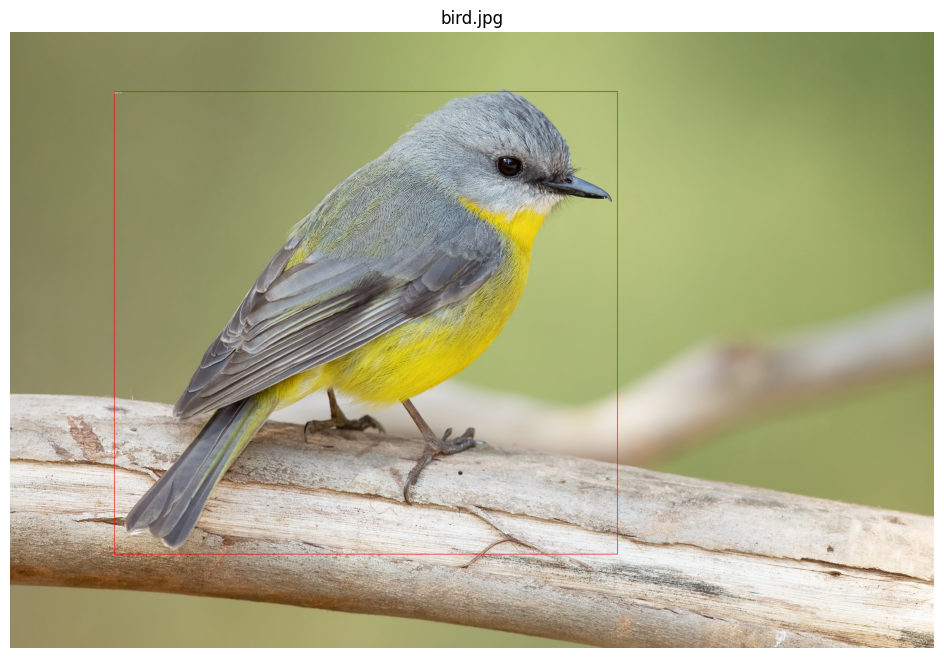


Processando cats_dog.png...
Detectado(s) 5 objeto(s) com confiança > 0.6:
 - cat: 0.999 em [637.28, 134.84, 854.92, 456.46]
 - dog: 0.995 em [240.69, 113.52, 763.25, 512.51]
 - bed: 0.614 em [-0.01, 287.31, 999.97, 555.99]
 - cat: 0.787 em [58.72, 241.11, 392.42, 492.42]
 - bed: 0.795 em [-0.07, 184.38, 999.92, 555.41]


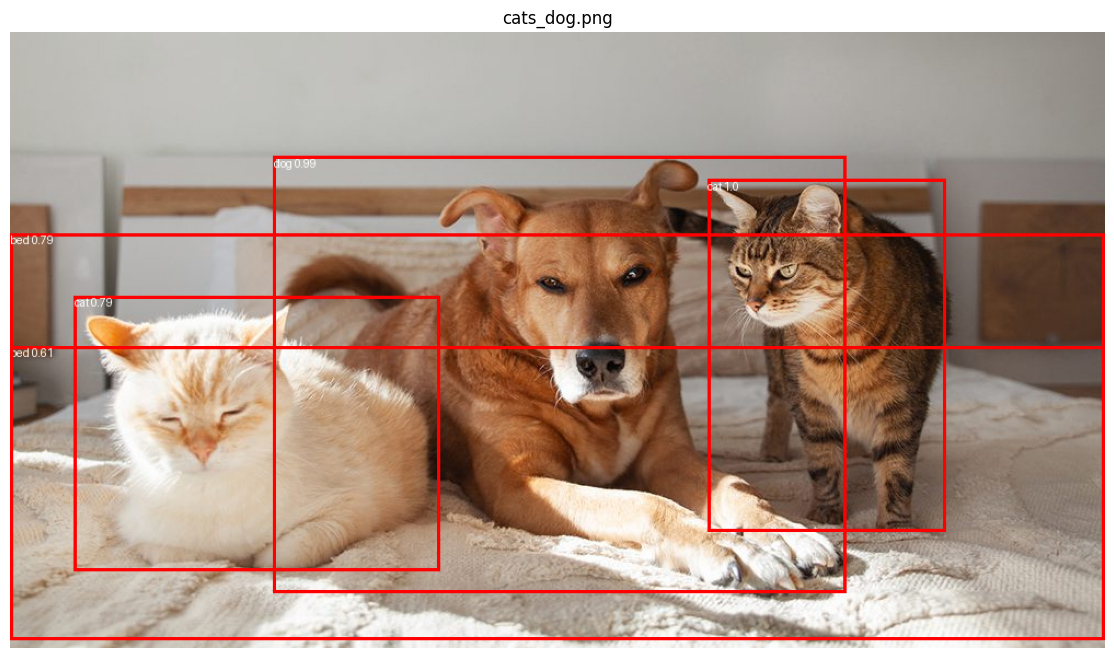


Processando kitchen.png...
Detectado(s) 11 objeto(s) com confiança > 0.6:
 - vase: 0.939 em [101.58, 267.28, 141.29, 364.53]
 - potted plant: 0.815 em [57.59, 185.44, 166.88, 363.52]
 - vase: 0.968 em [330.91, 96.18, 372.34, 151.26]
 - potted plant: 0.763 em [665.33, -0.06, 739.93, 79.0]
 - bottle: 0.918 em [290.39, 314.5, 326.19, 371.3]
 - bowl: 0.648 em [416.37, 337.24, 471.82, 366.71]
 - potted plant: 0.931 em [517.15, 261.19, 678.65, 348.17]
 - oven: 0.951 em [419.68, 406.77, 649.42, 491.39]
 - refrigerator: 0.843 em [0.36, 180.07, 71.84, 486.7]
 - bowl: 0.944 em [160.39, 327.41, 200.35, 352.5]
 - potted plant: 0.757 em [306.93, 43.62, 386.82, 150.69]


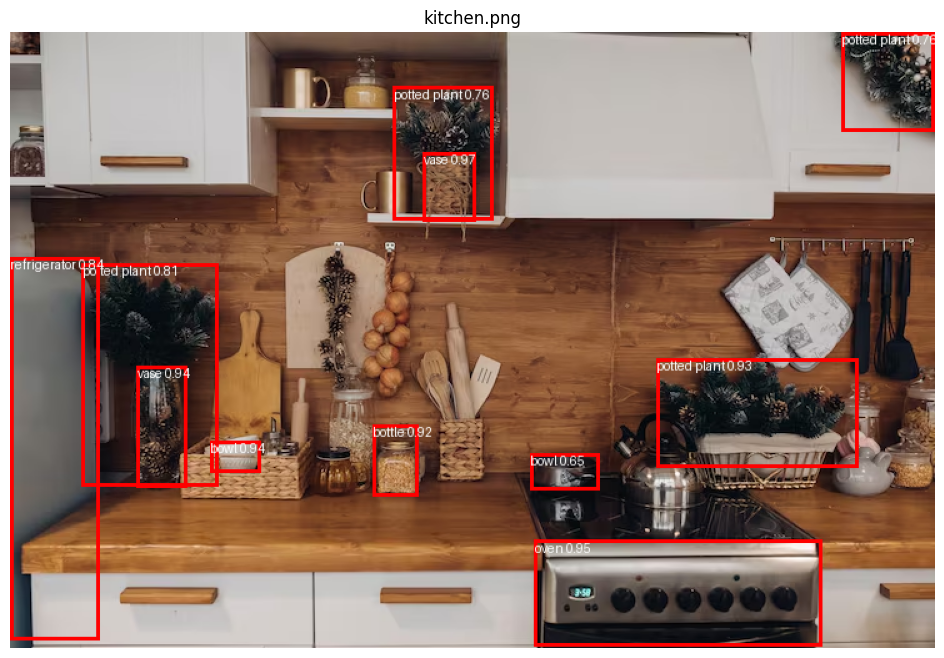


Processando pizza.png...
Detectado(s) 6 objeto(s) com confiança > 0.6:
 - pizza: 0.777 em [523.92, 438.9, 1019.36, 789.56]
 - pizza: 0.906 em [267.03, 458.13, 887.66, 925.93]
 - pizza: 0.876 em [9.6, 121.22, 1021.24, 920.04]
 - pizza: 0.814 em [5.48, 186.36, 507.0, 475.84]
 - pizza: 0.984 em [13.76, 432.38, 525.21, 866.52]
 - pizza: 0.662 em [296.83, 111.61, 790.47, 469.49]


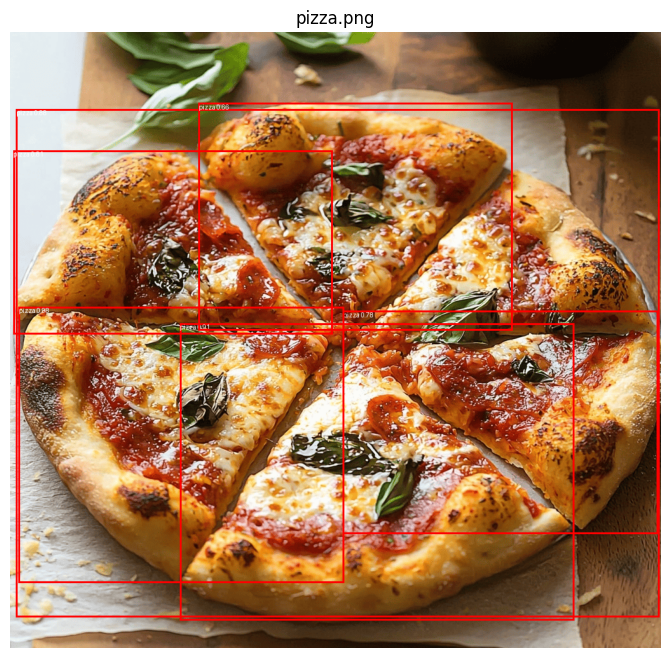

In [3]:
# 2. Listar e processar imagens da pasta "imagens"
image_dir = "imagens"

if not os.path.exists(image_dir):
    print(f"Erro: Pasta '{image_dir}' não encontrada.")
else:
    files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not files:
        print("Nenhuma imagem encontrada na pasta.")
    else:
        for file in files:
            path = os.path.join(image_dir, file)
            print(f"\nProcessando {file}...")
            detect_and_show(path)